# Import Library

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import os
import sys
import pickle
import warnings
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import optuna
import mlflow
import mlflow.sklearn

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Python:", sys.executable)
print("Folder kerja:", os.getcwd())

Python: c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\python.exe
Folder kerja: c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\notebook


# SetUp MLFlow

In [2]:
# ============================================================
# SETUP MLFLOW
# ============================================================
db_path = os.path.abspath("mlflow.db")
tracking_uri = f"sqlite:///{db_path}"

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("FaultSense_Coba")

subprocess.Popen([
    sys.executable, "-m", "mlflow", "ui",
    "--backend-store-uri", tracking_uri,
    "--port", "5002"
])

print("Tracking URI:", tracking_uri)
print("MLflow siap.")

Tracking URI: sqlite:///c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\notebook\mlflow.db
MLflow siap.


# Load Data

In [3]:
# ============================================================
# CONFIG PATH — jalankan cell ini sebelum yang lain
# ============================================================
import os

BASE_DIR   = os.path.abspath("..")  # naik dari notebook/ ke KODE/
DATA_PATH  = os.path.join(BASE_DIR, "data", "ai4i2020.csv")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("BASE_DIR  :", BASE_DIR)
print("DATA_PATH :", DATA_PATH)
print("MODEL_DIR :", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR  : c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode
DATA_PATH : c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\data\ai4i2020.csv
MODEL_DIR : c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\models
OUTPUT_DIR: c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\outputs


In [4]:
df = pd.read_csv(DATA_PATH)

# Pastikan timestamp terbaca sebagai datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Shape: {df.shape}")
print(f"Tipe timestamp: {df['timestamp'].dtype}")  # harusnya datetime64[ns]
print(f"Rentang: {df['timestamp'].min()} s/d {df['timestamp'].max()}")

Shape: (10000, 15)
Tipe timestamp: datetime64[ns]
Rentang: 1998-01-01 08:00:00 s/d 2026-05-02 23:09:00


# EDA

                           timestamp          UDI  Air temperature [K]  \
count                          10000  10000.00000         10000.000000   
mean   2012-03-02 15:34:20.159999744   5000.50000           300.004930   
min              1998-01-01 08:00:00      1.00000           295.300000   
25%              2005-01-31 11:47:15   2500.75000           298.300000   
50%              2012-03-02 15:34:30   5000.50000           300.100000   
75%              2019-04-02 19:21:45   7500.25000           301.500000   
max              2026-05-02 23:09:00  10000.00000           304.500000   
std                              NaN   2886.89568             2.000259   

       Process temperature [K]  Rotational speed [rpm]   Torque [Nm]  \
count             10000.000000            10000.000000  10000.000000   
mean                310.005560             1538.776100     39.986910   
min                 305.700000             1168.000000      3.800000   
25%                 308.800000             14

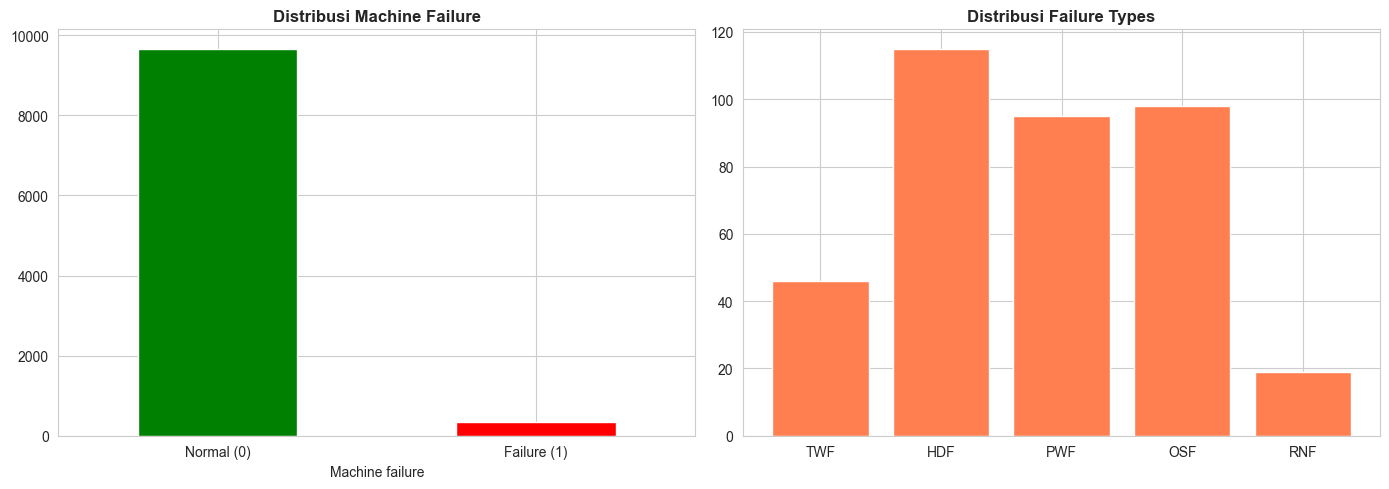

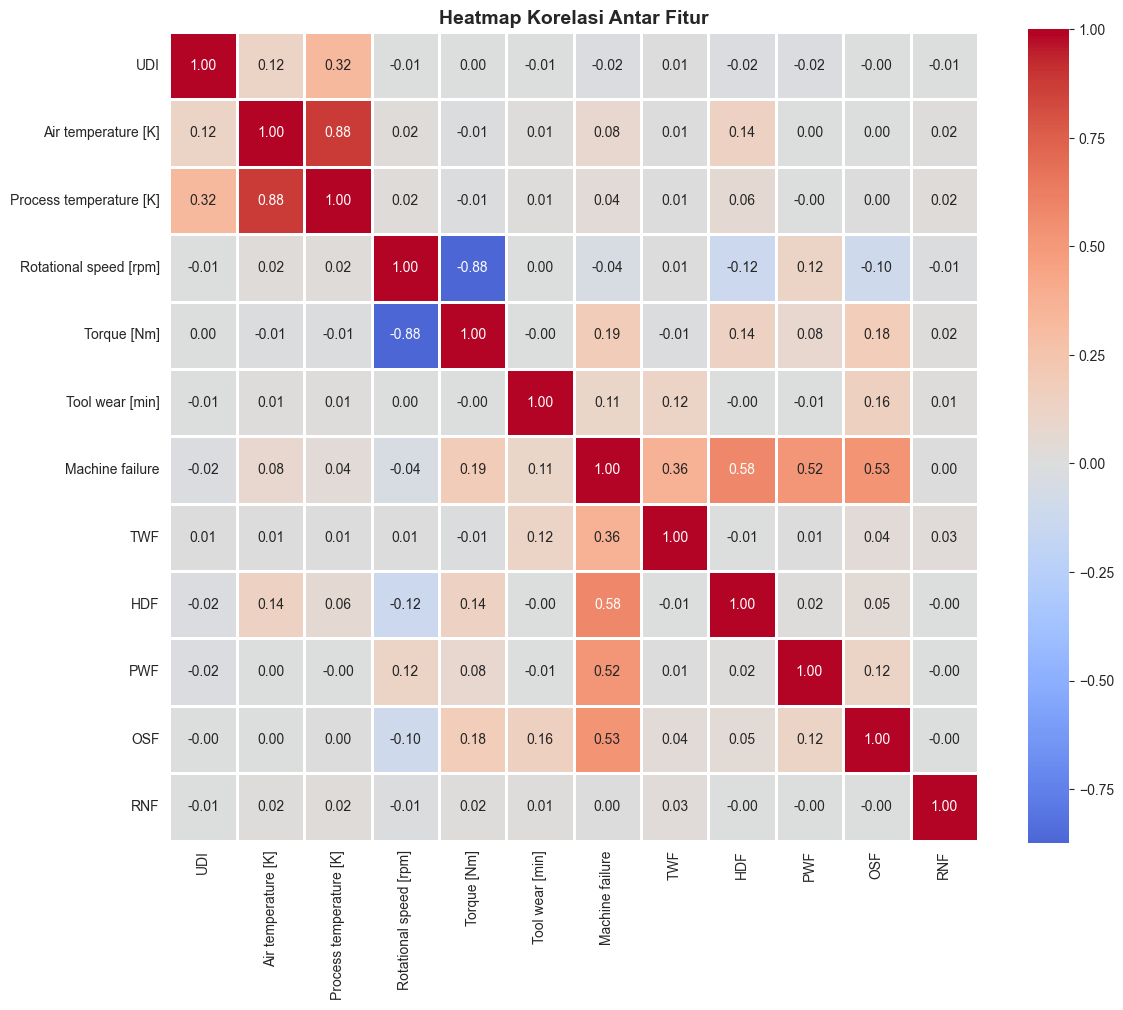

In [5]:
# ============================================================
# EDA
# ============================================================
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Statistik deskriptif
print(df.describe())

# Distribusi Machine Failure
print("\nDistribusi Machine Failure:")
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

# Distribusi Failure Types
print("\nDistribusi Failure Types:")
for ft in failure_types:
    count = df[ft].sum()
    print(f"  {ft}: {count} ({count/len(df)*100:.2f}%)")

# Plot distribusi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Machine failure'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribusi Machine Failure', fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Failure (1)'], rotation=0)

failure_counts = [df[ft].sum() for ft in failure_types]
axes[1].bar(failure_types, failure_counts, color='coral')
axes[1].set_title('Distribusi Failure Types', fontweight='bold')

plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Rentang waktu : 1998-01-01 s/d 2026-05-02
Total data    : 10000 hari pengecekan mesin

Distribusi per bulan (total pengecekan):
month
1     869
2     790
3     870
4     841
5     842
6     812
7     840
8     837
9     812
10    837
11    812
12    838


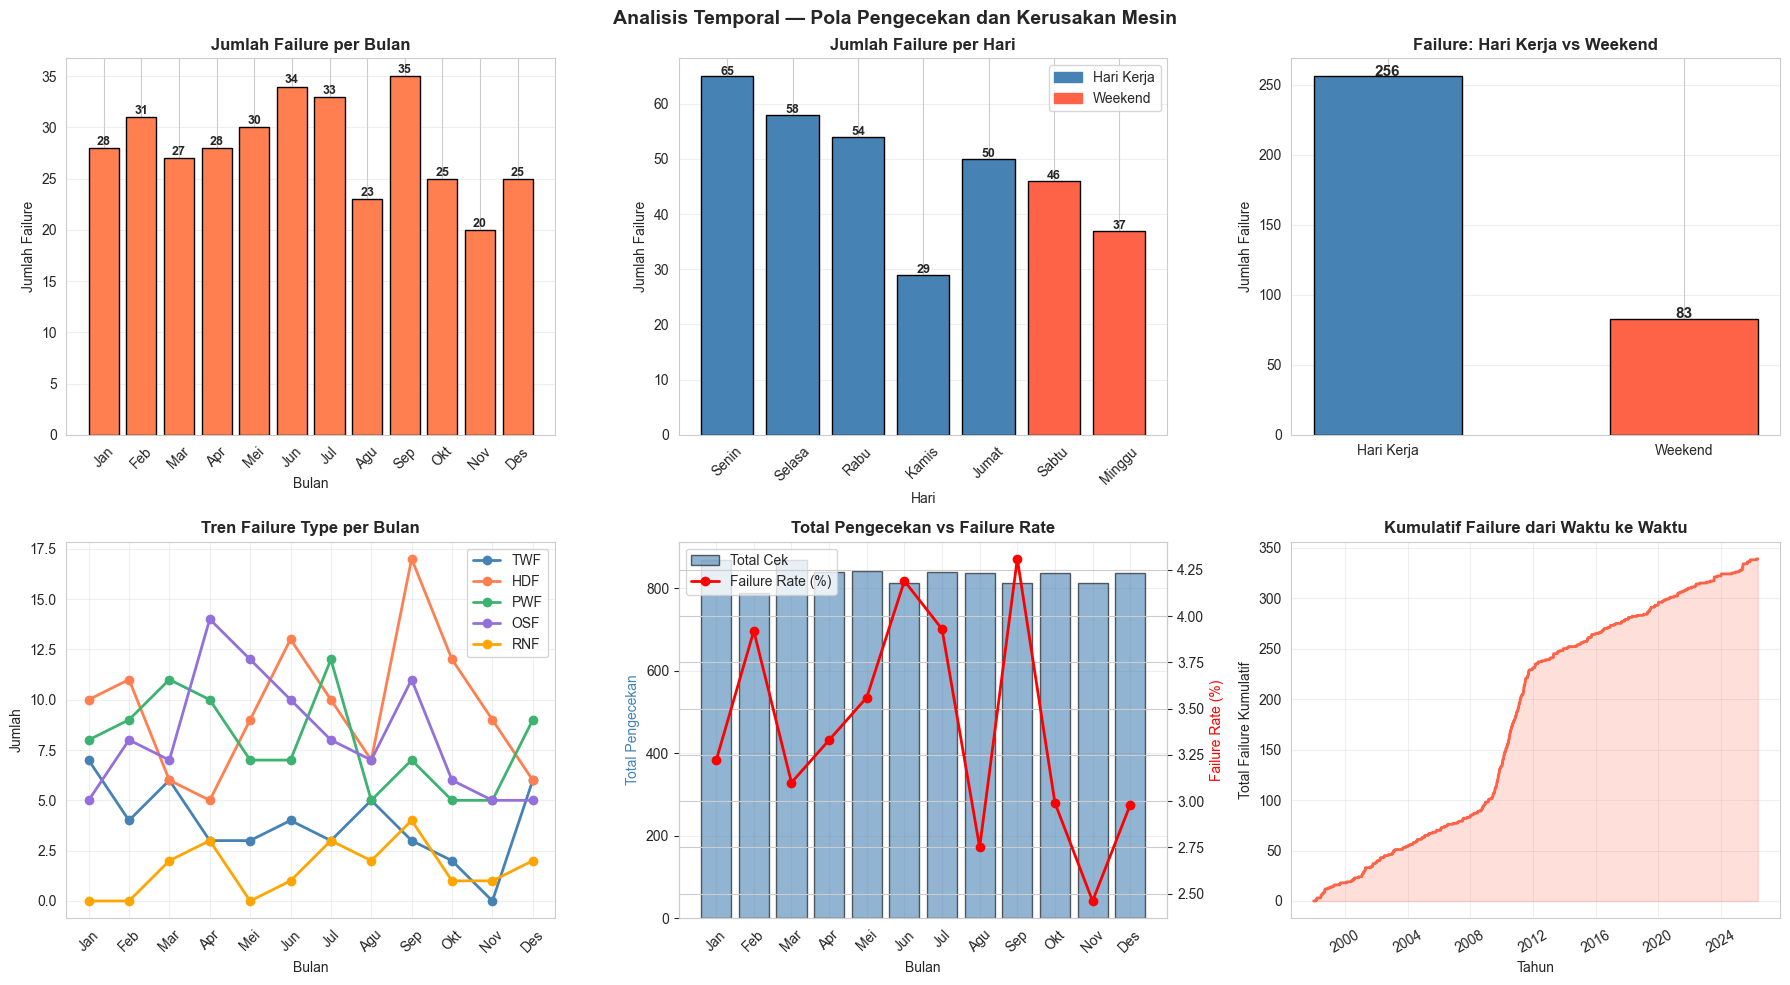

Visualisasi temporal disimpan ke outputs/eda_temporal.png

Catatan: Timestamp bersifat simulasi untuk keperluan analisis visual.
Fitur waktu TIDAK dimasukkan ke model prediksi.


In [6]:
# ============================================================
# EDA TEMPORAL — Analisis Pola Waktu
# Timestamp sudah ada di CSV, langsung ekstrak fitur waktu
# Catatan: fitur waktu TIDAK dimasukkan ke model
# ============================================================

# Ekstrak fitur waktu
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month']       = df['timestamp'].dt.month
df['is_weekend']  = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

day_names   = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

print(f"Rentang waktu : {df['timestamp'].min().date()} s/d {df['timestamp'].max().date()}")
print(f"Total data    : {len(df)} hari pengecekan mesin")
print(f"\nDistribusi per bulan (total pengecekan):")
print(df.groupby('month').size().to_string())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Failure per bulan
ax1 = axes[0, 0]
failure_per_month = df.groupby('month')['Machine failure'].sum()
ax1.bar(failure_per_month.index, failure_per_month.values,
        color='coral', edgecolor='black')
ax1.set_title('Jumlah Failure per Bulan', fontweight='bold')
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Jumlah Failure')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names, rotation=45)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(failure_per_month.values):
    ax1.text(failure_per_month.index[i], v + 0.3, str(v),
             ha='center', fontweight='bold', fontsize=9)

# 2. Failure per hari dalam seminggu
ax2 = axes[0, 1]
failure_per_day = df.groupby('day_of_week')['Machine failure'].sum()
colors_day = ['steelblue' if i < 5 else 'tomato' for i in failure_per_day.index]
ax2.bar(failure_per_day.index, failure_per_day.values,
        color=colors_day, edgecolor='black')
ax2.set_title('Jumlah Failure per Hari', fontweight='bold')
ax2.set_xlabel('Hari')
ax2.set_ylabel('Jumlah Failure')
ax2.set_xticks(range(7))
ax2.set_xticklabels(day_names, rotation=45)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(failure_per_day.values):
    ax2.text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=9)
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color='steelblue', label='Hari Kerja'),
    Patch(color='tomato',    label='Weekend')
])

# 3. Hari Kerja vs Weekend
ax3 = axes[0, 2]
weekend_group = df.groupby('is_weekend')['Machine failure'].sum()
ax3.bar(['Hari Kerja', 'Weekend'], weekend_group.values,
        color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
ax3.set_title('Failure: Hari Kerja vs Weekend', fontweight='bold')
ax3.set_ylabel('Jumlah Failure')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(weekend_group.values):
    ax3.text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=11)

# 4. Tren failure type per bulan
ax4 = axes[1, 0]
colors_ft = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'orange']
for ft, color in zip(failure_types, colors_ft):
    ft_per_month = df.groupby('month')[ft].sum()
    ax4.plot(ft_per_month.index, ft_per_month.values,
             marker='o', label=ft, color=color, lw=2)
ax4.set_title('Tren Failure Type per Bulan', fontweight='bold')
ax4.set_xlabel('Bulan')
ax4.set_ylabel('Jumlah')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_names, rotation=45)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Total pengecekan vs failure rate per bulan
ax5 = axes[1, 1]
total_per_month   = df.groupby('month').size()
failure_per_month = df.groupby('month')['Machine failure'].sum()
failure_rate      = (failure_per_month / total_per_month * 100).round(2)
ax5_twin = ax5.twinx()
ax5.bar(total_per_month.index, total_per_month.values,
        color='steelblue', alpha=0.6, edgecolor='black', label='Total Cek')
ax5_twin.plot(failure_rate.index, failure_rate.values,
              color='red', marker='o', lw=2, label='Failure Rate (%)')
ax5.set_title('Total Pengecekan vs Failure Rate', fontweight='bold')
ax5.set_xlabel('Bulan')
ax5.set_ylabel('Total Pengecekan', color='steelblue')
ax5_twin.set_ylabel('Failure Rate (%)', color='red')
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(month_names, rotation=45)
ax5.grid(alpha=0.3)
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 6. Kumulatif failure dari waktu ke waktu
ax6 = axes[1, 2]
df_sorted = df.sort_values('timestamp').copy()
df_sorted['cumulative_failure'] = df_sorted['Machine failure'].cumsum()
ax6.plot(df_sorted['timestamp'], df_sorted['cumulative_failure'],
         color='tomato', lw=2)
ax6.fill_between(df_sorted['timestamp'], df_sorted['cumulative_failure'],
                 alpha=0.2, color='tomato')
ax6.set_title('Kumulatif Failure dari Waktu ke Waktu', fontweight='bold')
ax6.set_xlabel('Tahun')
ax6.set_ylabel('Total Failure Kumulatif')
ax6.grid(alpha=0.3)
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Analisis Temporal — Pola Pengecekan dan Kerusakan Mesin',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_temporal.png"), dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi temporal disimpan ke outputs/eda_temporal.png")
print("\nCatatan: Timestamp bersifat simulasi untuk keperluan analisis visual.")
print("Fitur waktu TIDAK dimasukkan ke model prediksi.")

# Preprocessing

In [7]:
# ============================================================
# PREPROCESSING
# ============================================================
df_processed = df.copy()

# Drop kolom tidak relevan
df_processed = df_processed.drop(columns=['UDI', 'Product ID'])

# One-Hot Encoding kolom Type (H/L/M) — lebih benar untuk kategorikal nominal
df_processed = pd.get_dummies(df_processed, columns=['Type'], drop_first=False)

# Pastikan kolom OHE bertipe int (bukan bool)
for col in ['Type_H', 'Type_L', 'Type_M']:
    df_processed[col] = df_processed[col].astype(int)

print("Kolom setelah OHE:")
print(df_processed.columns.tolist())
print(f"\nShape: {df_processed.shape}")

Kolom setelah OHE:
['timestamp', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'hour', 'day_of_week', 'month', 'is_weekend', 'Type_H', 'Type_L', 'Type_M']

Shape: (10000, 19)


# Split & Scaling

In [8]:
# ============================================================
# SPLIT & SCALING — 8 fitur (OHE)
# Urutan fitur HARUS sama persis dengan input_array di prediction.py
# ============================================================
feature_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Type_H',
    'Type_L',
    'Type_M'
]

X = df_processed[feature_cols]
y = df_processed['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Jumlah fitur : {X_train.shape[1]} — {feature_cols}")

Training set : 8000 samples
Test set     : 2000 samples
Jumlah fitur : 8 — ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']


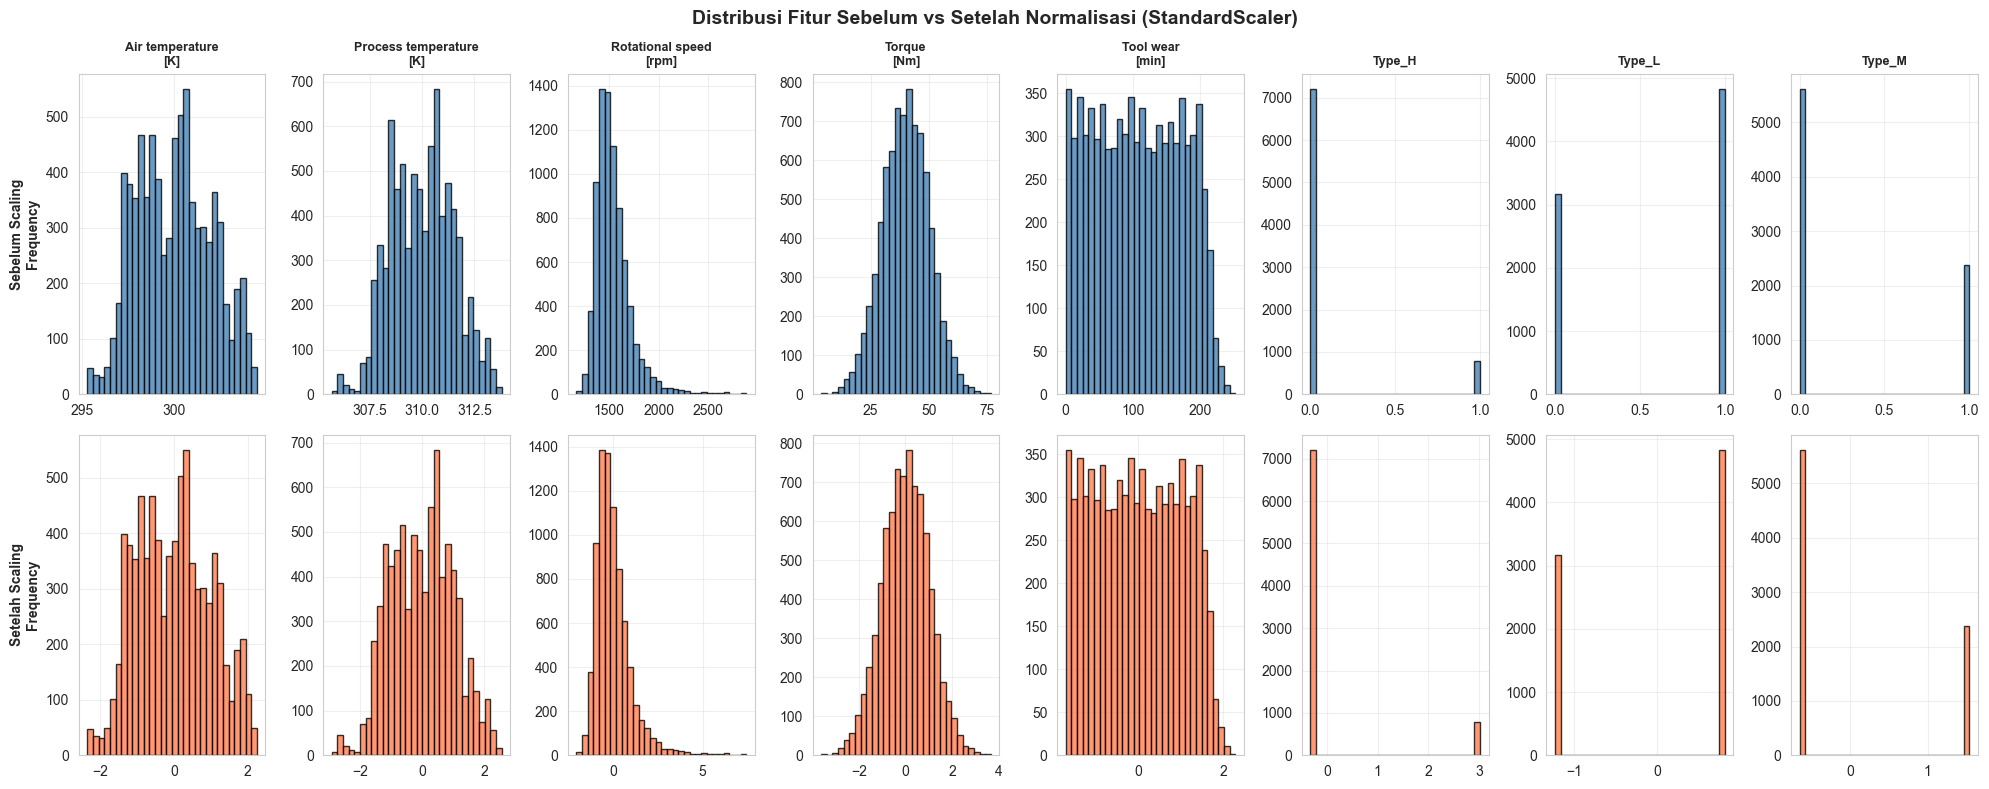

        STATISTIK SEBELUM SCALING (X_train)
       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]     Type_H     Type_L     Type_M
count            8000.0000                8000.0000               8000.0000    8000.0000         8000.000  8000.0000  8000.0000  8000.0000
mean              300.0054                 310.0061               1539.3569      40.0034          107.685     0.0986     0.6038     0.2976
std                 1.9968                   1.4794                180.9829      10.0195           63.612     0.2982     0.4891     0.4572
min               295.3000                 305.7000               1168.0000       3.8000            0.000     0.0000     0.0000     0.0000
25%               298.3000                 308.8000               1422.0000      33.2000           53.000     0.0000     0.0000     0.0000
50%               300.1000                 310.1000               1503.0000      40.1000          107.000     0.0000     1

In [9]:
# ============================================================
# VISUALISASI HASIL NORMALISASI (SCALING)
# ============================================================

fig, axes = plt.subplots(2, len(feature_cols), figsize=(20, 8))

for i, col in enumerate(feature_cols):
    # Baris atas — sebelum scaling
    axes[0, i].hist(X_train[col], bins=30, color='steelblue',
                    edgecolor='black', alpha=0.8)
    axes[0, i].set_title(col.replace(' [K]', '\n[K]')
                            .replace(' [rpm]', '\n[rpm]')
                            .replace(' [Nm]', '\n[Nm]')
                            .replace(' [min]', '\n[min]'),
                         fontsize=9, fontweight='bold')
    axes[0, i].set_ylabel('Frequency' if i == 0 else '')
    axes[0, i].grid(alpha=0.3)

    # Baris bawah — setelah scaling
    axes[1, i].hist(X_train_scaled[col], bins=30, color='coral',
                    edgecolor='black', alpha=0.8)
    axes[1, i].set_ylabel('Frequency' if i == 0 else '')
    axes[1, i].grid(alpha=0.3)

# Label baris
axes[0, 0].set_ylabel('Sebelum Scaling\nFrequency', fontweight='bold')
axes[1, 0].set_ylabel('Setelah Scaling\nFrequency', fontweight='bold')

plt.suptitle('Distribusi Fitur Sebelum vs Setelah Normalisasi (StandardScaler)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "normalisasi.png"), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# TABEL STATISTIK SEBELUM VS SETELAH
# ============================================================
print("=" * 70)
print("        STATISTIK SEBELUM SCALING (X_train)")
print("=" * 70)
print(X_train.describe().round(4).to_string())

print("\n")
print("=" * 70)
print("        STATISTIK SETELAH SCALING (X_train_scaled)")
print("=" * 70)
print(X_train_scaled.describe().round(4).to_string())

print("\n")
print("=" * 70)
print("   PERBANDINGAN MEAN DAN STD PER FITUR")
print("=" * 70)
print(f"\n{'Fitur':30} {'Mean Sebelum':>14} {'Mean Setelah':>14} {'Std Sebelum':>13} {'Std Setelah':>13}")
print("-" * 70)
for col in feature_cols:
    print(f"  {col:28} "
          f"{X_train[col].mean():>14.4f} "
          f"{X_train_scaled[col].mean():>14.4f} "
          f"{X_train[col].std():>13.4f} "
          f"{X_train_scaled[col].std():>13.4f}")

print("\nCatatan: Setelah StandardScaler, mean ≈ 0 dan std ≈ 1 untuk semua fitur.")

        DISTRIBUSI DATA SETELAH SPLIT

                                  TRAIN     TEST    TOTAL
-------------------------------------------------------
Total Data                         8000     2000    10000
Normal (0)                         7729     1932     9661
Failure (1)                         271       68      339
-------------------------------------------------------

Failure Type                      TRAIN     TEST    TOTAL
-------------------------------------------------------
  TWF                                36       10       46
  HDF                                86       29      115
  PWF                                82       13       95
  OSF                                82       16       98
  RNF                                15        4       19
-------------------------------------------------------

Proporsi Train                    80.0%
Proporsi Test                     20.0%


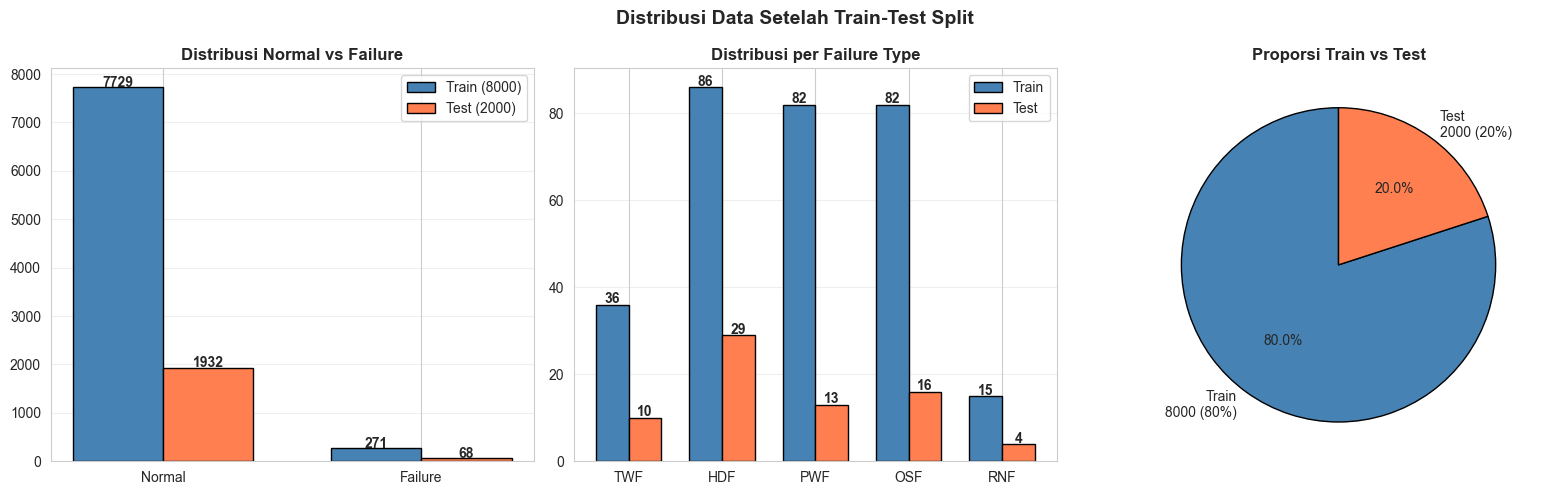


Visualisasi disimpan ke outputs/distribusi_split.png


In [10]:
# ============================================================
# RINGKASAN DISTRIBUSI SPLIT DATA
# ============================================================
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Ambil index train dan test
train_idx = X_train.index
test_idx  = X_test.index

# Hitung distribusi failure per split
print("=" * 55)
print("        DISTRIBUSI DATA SETELAH SPLIT")
print("=" * 55)

print(f"\n{'':30} {'TRAIN':>8} {'TEST':>8} {'TOTAL':>8}")
print("-" * 55)

# Machine failure
total_train  = len(y_train)
total_test   = len(y_test)
total_all    = len(y)

fail_train   = (y_train == 1).sum()
fail_test    = (y_test  == 1).sum()
fail_all     = (y       == 1).sum()

normal_train = (y_train == 0).sum()
normal_test  = (y_test  == 0).sum()
normal_all   = (y       == 0).sum()

print(f"{'Total Data':30} {total_train:>8} {total_test:>8} {total_all:>8}")
print(f"{'Normal (0)':30} {normal_train:>8} {normal_test:>8} {normal_all:>8}")
print(f"{'Failure (1)':30} {fail_train:>8} {fail_test:>8} {fail_all:>8}")

print("-" * 55)

# Per failure type
print(f"\n{'Failure Type':30} {'TRAIN':>8} {'TEST':>8} {'TOTAL':>8}")
print("-" * 55)

for ft in failure_types:
    ft_all   = df_processed[ft].sum()
    ft_train = df_processed.loc[train_idx, ft].sum()
    ft_test  = df_processed.loc[test_idx,  ft].sum()
    print(f"  {ft:28} {ft_train:>8} {ft_test:>8} {ft_all:>8}")

print("-" * 55)

# Persentase split
print(f"\n{'Proporsi Train':30} {total_train/total_all*100:>7.1f}%")
print(f"{'Proporsi Test':30} {total_test/total_all*100:>7.1f}%")

# ============================================================
# VISUALISASI
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Total split
ax1 = axes[0]
categories = ['Normal', 'Failure']
train_vals = [normal_train, fail_train]
test_vals  = [normal_test,  fail_test]
x = np.arange(len(categories))
w = 0.35

bars1 = ax1.bar(x - w/2, train_vals, w, label=f'Train ({total_train})', color='steelblue',  edgecolor='black')
bars2 = ax1.bar(x + w/2, test_vals,  w, label=f'Test ({total_test})',   color='coral', edgecolor='black')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

ax1.set_title('Distribusi Normal vs Failure', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2 — Per failure type
ax2 = axes[1]
ft_train_vals = [df_processed.loc[train_idx, ft].sum() for ft in failure_types]
ft_test_vals  = [df_processed.loc[test_idx,  ft].sum() for ft in failure_types]
x2 = np.arange(len(failure_types))

bars3 = ax2.bar(x2 - w/2, ft_train_vals, w, label='Train', color='steelblue', edgecolor='black')
bars4 = ax2.bar(x2 + w/2, ft_test_vals,  w, label='Test',  color='coral', edgecolor='black')

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

ax2.set_title('Distribusi per Failure Type', fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(failure_types)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3 — Proporsi pie chart
ax3 = axes[2]
ax3.pie(
    [total_train, total_test],
    labels=[f'Train\n{total_train} ({total_train/total_all*100:.0f}%)',
            f'Test\n{total_test} ({total_test/total_all*100:.0f}%)'],
    colors=['steelblue', 'coral'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
ax3.set_title('Proporsi Train vs Test', fontweight='bold')

plt.suptitle('Distribusi Data Setelah Train-Test Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distribusi_split.png"), dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualisasi disimpan ke outputs/distribusi_split.png")

# SMOTE

In [11]:
# ============================================================
# SMOTE — dijalankan dari X_train_SCALED, bukan X_train mentah
# ============================================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Shape sebelum SMOTE : {X_train_scaled.shape}")
print(f"Shape setelah SMOTE : {X_train_resampled.shape}")
print(f"\nDistribusi setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Shape sebelum SMOTE : (8000, 8)
Shape setelah SMOTE : (15458, 8)

Distribusi setelah SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


# Prepare Multiclass Labels

In [12]:
# ============================================================
# PREPARE MULTICLASS LABELS
# Bug #5 fix: tambah penanganan jika satu baris punya
#             lebih dari satu failure type aktif
# Bug #3 fix: definisikan all_class_labels di sini
# ============================================================
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
label_map = {'TWF': 0, 'HDF': 1, 'PWF': 2, 'OSF': 3, 'RNF': 4}
all_class_labels = [0, 1, 2, 3, 4]   # <-- Bug #3 fix: didefinisikan di sini

def get_failure_label(row):
    """
    Jika hanya satu failure type aktif → pakai itu.
    Jika lebih dari satu aktif → pakai yang pertama ditemukan (sesuai urutan failure_types).
    Ini lebih eksplisit daripada idxmax() yang diam-diam memilih kolom pertama.
    """
    active = [ft for ft in failure_types if row[ft] == 1]
    if len(active) == 0:
        return None   # baris ini bukan failure — akan difilter
    return label_map[active[0]]

# --- TRAIN ---
train_failure_idx = y_train[y_train == 1].index
failure_df_train  = df_processed.loc[train_failure_idx, failure_types]
y_train_multi     = failure_df_train.apply(get_failure_label, axis=1).dropna().astype(int)
X_train_multi     = X_train_scaled.loc[y_train_multi.index]

# --- TEST ---
test_failure_idx  = y_test[y_test == 1].index
failure_df_test   = df_processed.loc[test_failure_idx, failure_types]
y_test_multi      = failure_df_test.apply(get_failure_label, axis=1).dropna().astype(int)
X_test_multi      = X_test_scaled.loc[y_test_multi.index]

print(f"Failure cases train : {len(X_train_multi)}")
print(f"Failure cases test  : {len(X_test_multi)}")

print("\nDistribusi failure types (train):")
for ft, i in label_map.items():
    count = (y_train_multi == i).sum()
    print(f"  {ft} ({i}): {count} ({count/len(y_train_multi)*100:.1f}%)")

Failure cases train : 264
Failure cases test  : 66

Distribusi failure types (train):
  TWF (0): 36 (13.6%)
  HDF (1): 86 (32.6%)
  PWF (2): 79 (29.9%)
  OSF (3): 63 (23.9%)
  RNF (4): 0 (0.0%)


# Baseline Models

In [13]:
# ============================================================
# BASELINE MODELS — minimal 3 sesuai requirement
# Model: Random Forest, Logistic Regression, Gradient Boosting
# Semua dilatih dari X_train_resampled (post-SMOTE, post-scaling)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

baseline_models = {
    "Baseline_RandomForest_B"    : RandomForestClassifier(
        n_estimators=100, random_state=42,
        n_jobs=-1, class_weight='balanced'
    ),
    "Baseline_LogisticRegression": LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    "Baseline_GradientBoosting"  : GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

baseline_results = {}

for model_name, model in baseline_models.items():
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print('='*50)

    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy"          : accuracy_score(y_test, y_pred),
        "recall_failure"    : recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "precision_failure" : precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_failure"        : f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc"           : roc_auc_score(y_test, y_prob)
    }

    baseline_results[model_name] = metrics

    print(f"  Accuracy          : {metrics['accuracy']:.4f}")
    print(f"  Recall Failure    : {metrics['recall_failure']:.4f}")
    print(f"  Precision Failure : {metrics['precision_failure']:.4f}")
    print(f"  F1-Score Failure  : {metrics['f1_failure']:.4f}")
    print(f"  ROC-AUC           : {metrics['roc_auc']:.4f}")

    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("training_data", "SMOTE + scaled")
        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, model_name)
        print(f"  → Dicatat ke MLflow.")

# Ringkasan perbandingan baseline
print("\n\n=== RINGKASAN BASELINE ===")
baseline_df = pd.DataFrame(baseline_results).T
print(baseline_df.to_string())


Training: Baseline_RandomForest_B
  Accuracy          : 0.9635
  Recall Failure    : 0.7500
  Precision Failure : 0.4766
  F1-Score Failure  : 0.5829
  ROC-AUC           : 0.9690


2026/05/05 00:50:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:50:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  → Dicatat ke MLflow.

Training: Baseline_LogisticRegression


2026/05/05 00:50:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:50:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Accuracy          : 0.8315
  Recall Failure    : 0.8382
  Precision Failure : 0.1488
  F1-Score Failure  : 0.2528
  ROC-AUC           : 0.9074
  → Dicatat ke MLflow.

Training: Baseline_GradientBoosting


2026/05/05 00:50:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:50:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Accuracy          : 0.9220
  Recall Failure    : 0.8971
  Precision Failure : 0.2905
  F1-Score Failure  : 0.4388
  ROC-AUC           : 0.9694
  → Dicatat ke MLflow.


=== RINGKASAN BASELINE ===
                             accuracy  recall_failure  precision_failure  f1_failure   roc_auc
Baseline_RandomForest_B        0.9635        0.750000           0.476636    0.582857  0.969013
Baseline_LogisticRegression    0.8315        0.838235           0.148825    0.252772  0.907434
Baseline_GradientBoosting      0.9220        0.897059           0.290476    0.438849  0.969416


# Optuna Tuning Binary 

In [14]:
# ============================================================
# OPTUNA TUNING — BINARY CLASSIFICATION
# Objective: maximize weighted score (recall + precision)
# ============================================================
def objective_binary(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 2, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state': 42, 'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    cv    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X_train_resampled, y_train_resampled, cv=cv)

    recall    = recall_score(y_train_resampled, y_pred, pos_label=1, zero_division=0)
    precision = precision_score(y_train_resampled, y_pred, pos_label=1, zero_division=0)
    return (0.65 * recall) + (0.35 * precision)

study_binary = optuna.create_study(direction='maximize', study_name='binary_recall')
study_binary.optimize(objective_binary, n_trials=50, show_progress_bar=True)

print(f"\nBest CV Score : {study_binary.best_value:.4f}")
print("Best Params   :", study_binary.best_params)

# Train ulang dengan best params
best_params_binary = {**study_binary.best_params, 'random_state': 42, 'n_jobs': -1}
rf_binary_tuned = RandomForestClassifier(**best_params_binary)
rf_binary_tuned.fit(X_train_resampled, y_train_resampled)
print("\nModel binary tuned selesai dilatih.")

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV Score : 0.9741
Best Params   : {'n_estimators': 413, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced'}

Model binary tuned selesai dilatih.


# Evaluasi Binary + Threshold Tuning 

In [15]:
# ============================================================
# THRESHOLD TUNING — hanya satu blok, pakai X_test_SCALED
# Bug #4 fix: sebelumnya ada dua blok threshold tuning
#             dengan input berbeda (scaled vs unscaled)
# ============================================================
y_prob_tuned = rf_binary_tuned.predict_proba(X_test_scaled)[:, 1]

thresholds   = np.arange(0.05, 0.90, 0.01)
results      = []

for thresh in thresholds:
    y_pred_t = (y_prob_tuned >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    results.append({
        "threshold" : thresh,
        "recall"    : recall_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        "precision" : precision_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        "f1"        : f1_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    })

results_df   = pd.DataFrame(results)
min_precision = 0.50
candidate_df  = results_df[results_df["precision"] >= min_precision]

if len(candidate_df) > 0:
    best_row = candidate_df.sort_values(by=["recall", "f1"], ascending=False).iloc[0]
    strategy = f"Max Recall dengan Precision >= {min_precision}"
else:
    best_row = results_df.sort_values(by=["recall", "f1"], ascending=False).iloc[0]
    strategy = "Fallback: Max Recall tanpa batas precision"

best_threshold    = best_row["threshold"]
y_pred_final      = (y_prob_tuned >= best_threshold).astype(int)

print(f"Strategi  : {strategy}")
print(f"Threshold : {best_threshold:.2f}")
print(f"Recall    : {best_row['recall']:.4f}")
print(f"Precision : {best_row['precision']:.4f}")
print(f"F1        : {best_row['f1']:.4f}")

# Simpan threshold untuk deployment API
os.makedirs("models", exist_ok=True)
with open(os.path.join(MODEL_DIR, "threshold.pkl"), "wb") as f:
    pickle.dump(float(best_threshold), f)
print(f"\nThreshold disimpan ke models/threshold.pkl")

# Log ke MLflow
with mlflow.start_run(run_name="Threshold_Tuning"):
    mlflow.log_param("selection_strategy", strategy)
    mlflow.log_param("default_threshold", 0.50)
    mlflow.log_param("best_threshold", float(best_threshold))
    mlflow.log_param("min_precision_constraint", 0.30)
    mlflow.log_metric("test_recall_failure",    float(best_row['recall']))
    mlflow.log_metric("test_precision_failure", float(best_row['precision']))
    mlflow.log_metric("test_f1_failure",        float(best_row['f1']))
    mlflow.log_metric("test_roc_auc",           float(roc_auc_score(y_test, y_prob_tuned)))
    mlflow.sklearn.log_model(rf_binary_tuned, "Binary_RandomForest_Op")
    print("Dicatat ke MLflow — Threshold_Tuning.")

2026/05/05 00:52:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:52:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Strategi  : Max Recall dengan Precision >= 0.5
Threshold : 0.55
Recall    : 0.7794
Precision : 0.5048
F1        : 0.6127

Threshold disimpan ke models/threshold.pkl
Dicatat ke MLflow — Threshold_Tuning.


# Optuna Tuning Multiclass + Evaluasi Final

In [16]:
# ============================================================
# OPTUNA TUNING — MULTICLASS
# ============================================================
def objective_multiclass(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state': 42, 'n_jobs': -1
    }
    model  = RandomForestClassifier(**params)
    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X_train_multi, y_train_multi, cv=cv)
    return f1_score(y_train_multi, y_pred, average='macro', zero_division=0)

study_multiclass = optuna.create_study(direction='maximize', study_name='multiclass_f1macro')
study_multiclass.optimize(objective_multiclass, n_trials=50, show_progress_bar=True)

best_params_multi   = {**study_multiclass.best_params, 'random_state': 42, 'n_jobs': -1}
rf_multiclass_tuned = RandomForestClassifier(**best_params_multi)
rf_multiclass_tuned.fit(X_train_multi, y_train_multi)

y_pred_multi = rf_multiclass_tuned.predict(X_test_multi)

# ============================================================
# EVALUASI FINAL — BINARY + MULTICLASS
# ============================================================
print("=" * 60)
print("        EVALUASI FINAL MODEL FAULTSENSE")
print("=" * 60)

acc_val    = accuracy_score(y_test, y_pred_final)
recall_val = recall_score(y_test, y_pred_final, pos_label=1, zero_division=0)
f1_bin_val = f1_score(y_test, y_pred_final, pos_label=1, zero_division=0)
auc_val    = roc_auc_score(y_test, y_prob_tuned)
f1_mac_val = f1_score(y_test_multi, y_pred_multi,
                      average='macro', labels=all_class_labels, zero_division=0)

print(f"\nBINARY CLASSIFICATION")
print(f"  Accuracy        : {acc_val:.4f}")
print(f"  Recall Failure  : {recall_val:.4f}")
print(f"  F1-Score Failure: {f1_bin_val:.4f}")
print(f"  ROC-AUC         : {auc_val:.4f}")
print(f"  Threshold       : {best_threshold:.2f}")

print(f"\nMULTICLASS CLASSIFICATION (Jenis Failure)")
print(f"  F1-Macro        : {f1_mac_val:.4f}")

print(f"\n--- Classification Report Binary ---")
print(classification_report(y_test, y_pred_final,
      target_names=['Normal', 'Failure'], zero_division=0))

print(f"\n--- Classification Report Multiclass ---")
print(classification_report(y_test_multi, y_pred_multi,
      labels=all_class_labels, target_names=failure_types, zero_division=0))

# ============================================================
# MLFLOW — pisah jadi dua run sesuai struktur yang ada
# ============================================================

# Run 1: Multiclass Model
with mlflow.start_run(run_name="Multiclass_Model_Optuna"):
    mlflow.log_params(best_params_multi)
    mlflow.log_metric("best_f1_macro_cv", float(study_multiclass.best_value))
    mlflow.log_metric("test_f1_macro",    float(f1_mac_val))
    mlflow.sklearn.log_model(rf_multiclass_tuned, "model_multiclass_rf")
    print("Dicatat ke MLflow — Multiclass_Model_Optuna.")

# Run 2: Final Artifacts — semua metrik final + semua model
with mlflow.start_run(run_name="Final_Artifacts"):
    mlflow.log_param("best_threshold",     float(best_threshold))
    mlflow.log_param("threshold_strategy", strategy)

    mlflow.log_metric("final_accuracy",             float(acc_val))
    mlflow.log_metric("final_recall_failure",       float(recall_val))
    mlflow.log_metric("final_f1_failure",           float(f1_bin_val))
    mlflow.log_metric("final_roc_auc",              float(auc_val))
    mlflow.log_metric("final_f1_macro_multiclass",  float(f1_mac_val))

    mlflow.sklearn.log_model(rf_binary_tuned,    "model_binary_rf")
    mlflow.sklearn.log_model(rf_multiclass_tuned,"model_multiclass_rf")

    mlflow.log_artifact(os.path.join(MODEL_DIR,  "threshold.pkl"))

    print("Dicatat ke MLflow — Final_Artifacts.")

  0%|          | 0/50 [00:00<?, ?it/s]

2026/05/05 00:53:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:53:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


        EVALUASI FINAL MODEL FAULTSENSE

BINARY CLASSIFICATION
  Accuracy        : 0.9665
  Recall Failure  : 0.7794
  F1-Score Failure: 0.6127
  ROC-AUC         : 0.9759
  Threshold       : 0.55

MULTICLASS CLASSIFICATION (Jenis Failure)
  F1-Macro        : 0.6772

--- Classification Report Binary ---
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      1932
     Failure       0.50      0.78      0.61        68

    accuracy                           0.97      2000
   macro avg       0.75      0.88      0.80      2000
weighted avg       0.98      0.97      0.97      2000


--- Classification Report Multiclass ---
              precision    recall  f1-score   support

         TWF       0.78      0.70      0.74        10
         HDF       1.00      0.93      0.96        29
         PWF       0.79      0.92      0.85        12
         OSF       0.81      0.87      0.84        15
         RNF       0.00      0.00      0.00         0

 

2026/05/05 00:53:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:53:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Dicatat ke MLflow — Multiclass_Model_Optuna.


2026/05/05 00:53:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:53:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Dicatat ke MLflow — Final_Artifacts.


# Visualisasi Evaluasi Model

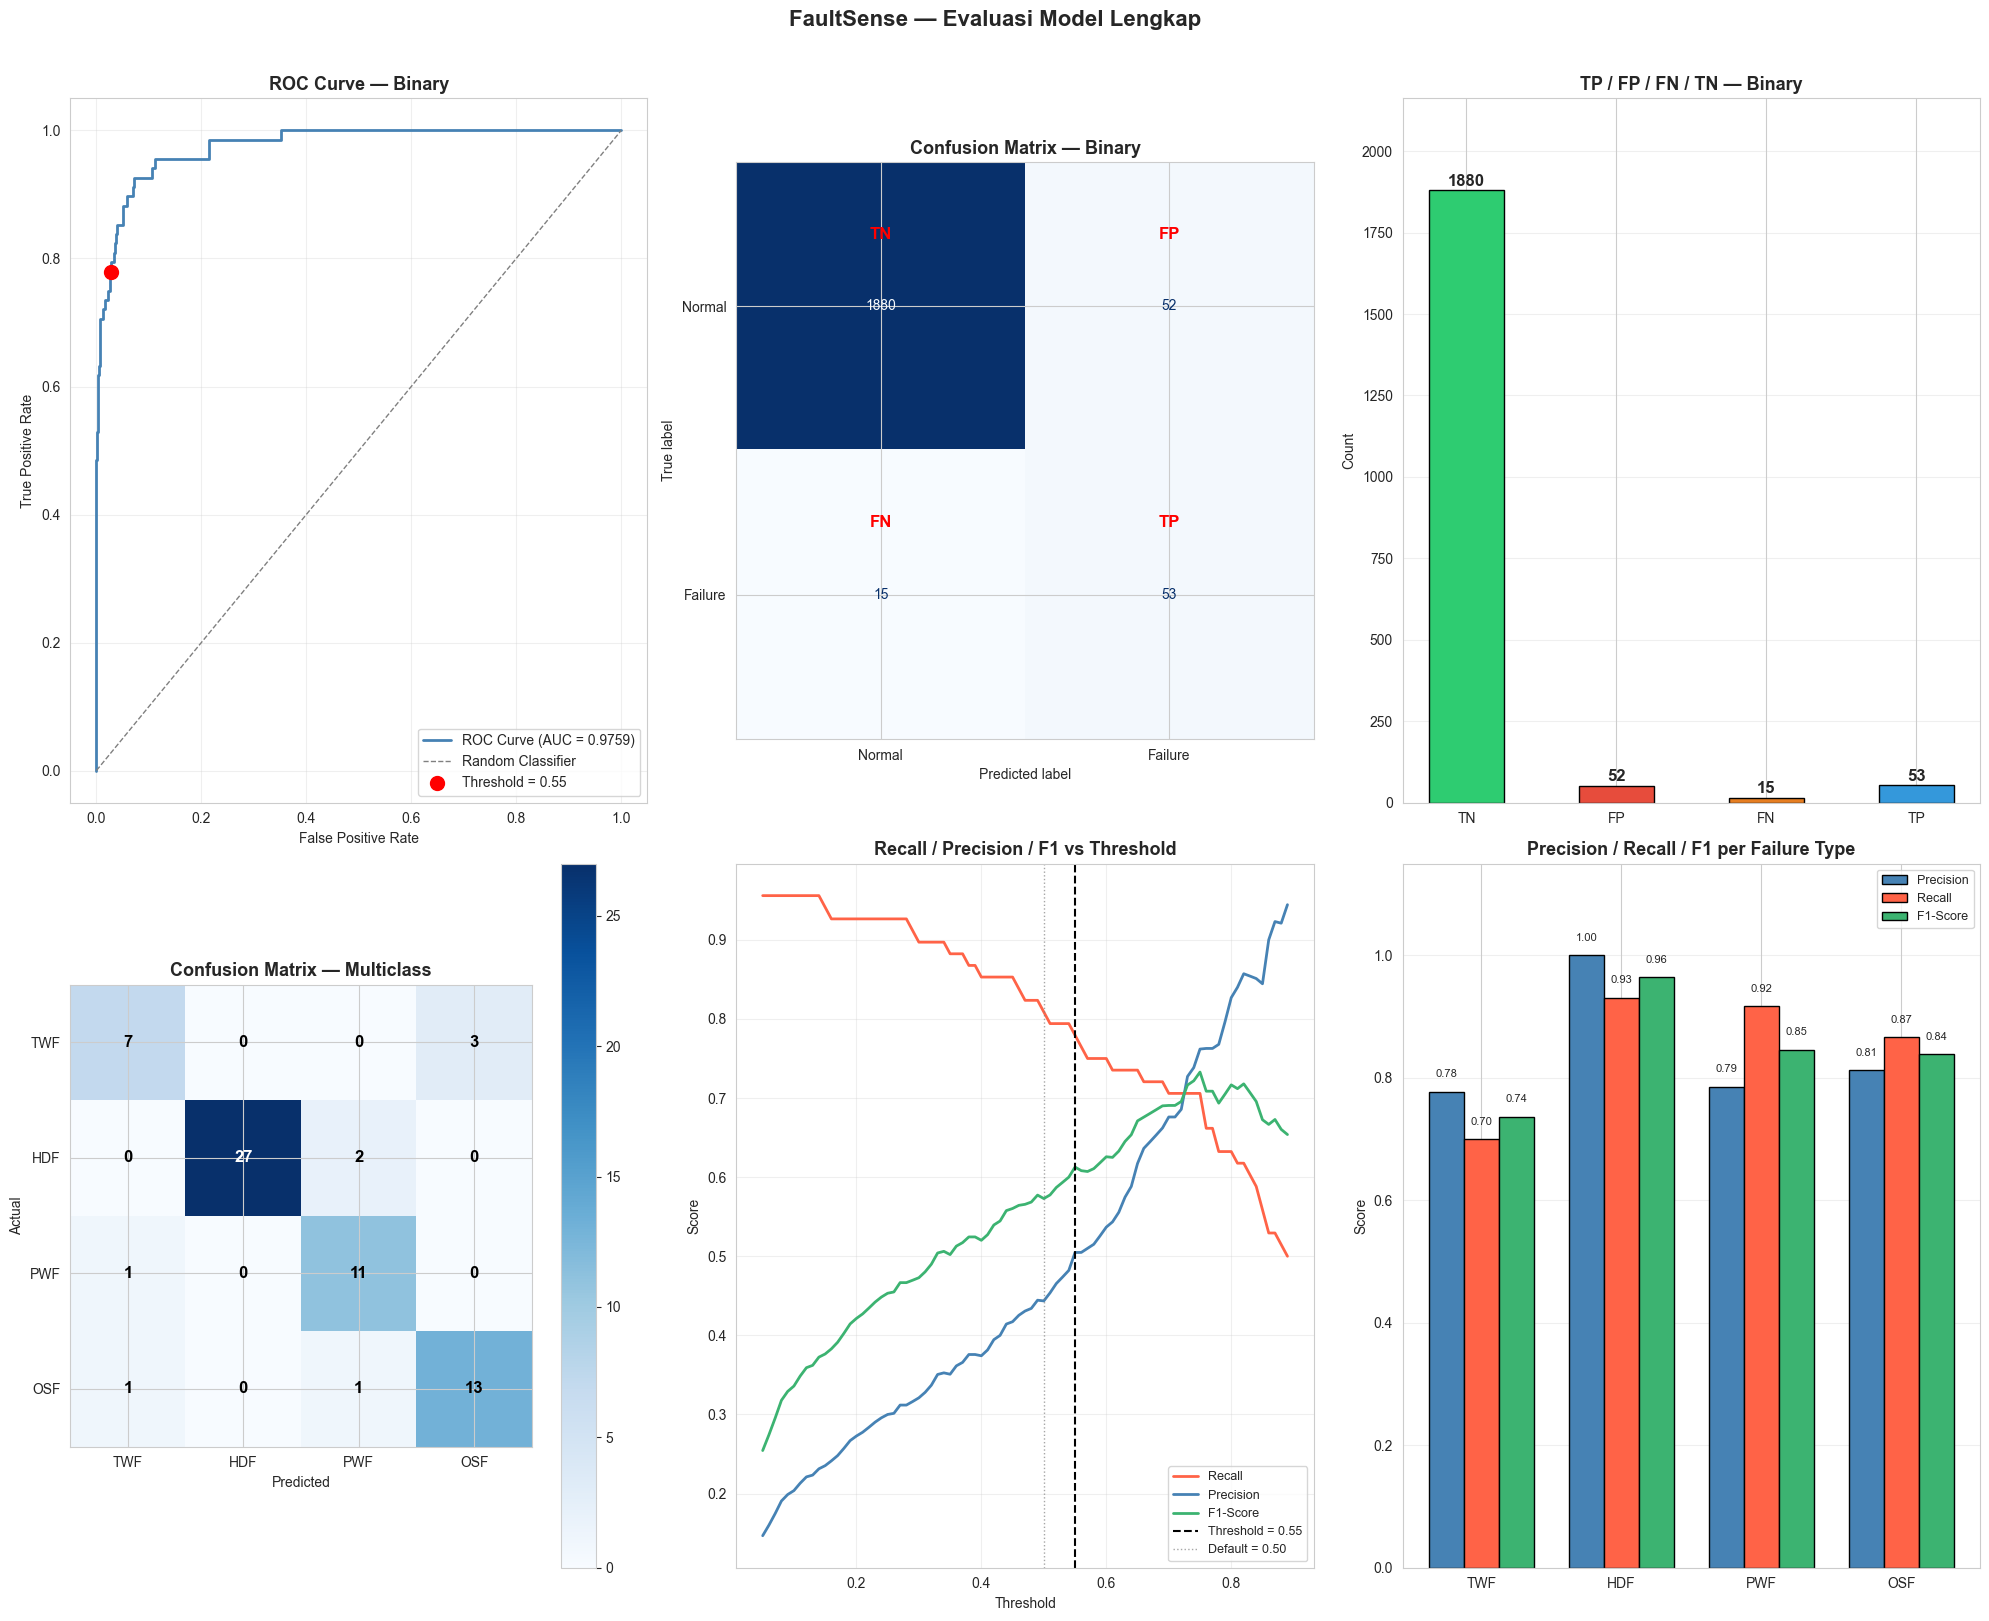

Visualisasi disimpan ke outputs/evaluasi_model_lengkap.png


In [17]:
# ============================================================
# VISUALISASI EVALUASI MODEL
# ============================================================
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

fig = plt.figure(figsize=(20, 16))

# ============================================================
# 1. ROC CURVE - BINARY
# ============================================================
ax1 = fig.add_subplot(2, 3, 1)
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
ax1.scatter(
    best_row['fp'] / (best_row['fp'] + best_row['tn']),
    best_row['tp'] / (best_row['tp'] + best_row['fn']),
    color='red', s=100, zorder=5, label=f'Threshold = {best_threshold:.2f}'
)
ax1.set_title('ROC Curve — Binary', fontweight='bold', fontsize=13)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(alpha=0.3)

# ============================================================
# 2. CONFUSION MATRIX - BINARY
# ============================================================
ax2 = fig.add_subplot(2, 3, 2)
cm_bin = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_bin.ravel()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bin,
    display_labels=['Normal', 'Failure']
)
disp.plot(ax=ax2, cmap='Blues', colorbar=False, values_format='d')
ax2.set_title('Confusion Matrix — Binary', fontweight='bold', fontsize=13)

# Tambah label TP/TN/FP/FN
for (i, j), val in np.ndenumerate(cm_bin):
    label = {(0,0): 'TN', (0,1): 'FP', (1,0): 'FN', (1,1): 'TP'}[(i,j)]
    ax2.text(j, i - 0.25, label, ha='center', va='center',
             fontsize=12, fontweight='bold', color='red')

# ============================================================
# 3. TP / FP / FN / TN BAR CHART - BINARY
# ============================================================
ax3 = fig.add_subplot(2, 3, 3)
labels_bar = ['TN', 'FP', 'FN', 'TP']
values_bar = [tn, fp, fn, tp]
colors_bar = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']

bars = ax3.bar(labels_bar, values_bar, color=colors_bar, edgecolor='black', width=0.5)
ax3.set_title('TP / FP / FN / TN — Binary', fontweight='bold', fontsize=13)
ax3.set_ylabel('Count')

for bar, val in zip(bars, values_bar):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax3.set_ylim(0, max(values_bar) * 1.15)
ax3.grid(axis='y', alpha=0.3)

# ============================================================
# 4. CONFUSION MATRIX - MULTICLASS
# ============================================================
ax4 = fig.add_subplot(2, 3, 4)

classes_in_test = sorted(y_test_multi.unique())
labels_in_test  = [failure_types[i] for i in classes_in_test]
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=classes_in_test)

im = ax4.imshow(cm_multi, cmap='Blues')
ax4.set_title('Confusion Matrix — Multiclass', fontweight='bold', fontsize=13)
ax4.set_xticks(range(len(classes_in_test)))
ax4.set_yticks(range(len(classes_in_test)))
ax4.set_xticklabels(labels_in_test)
ax4.set_yticklabels(labels_in_test)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

for i in range(len(classes_in_test)):
    for j in range(len(classes_in_test)):
        ax4.text(j, i, cm_multi[i, j], ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if cm_multi[i, j] > cm_multi.max()/2 else 'black')

plt.colorbar(im, ax=ax4)

# ============================================================
# 5. RECALL / PRECISION / F1 VS THRESHOLD
# ============================================================
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(results_df["threshold"], results_df["recall"],    label='Recall',    color='tomato',       lw=2)
ax5.plot(results_df["threshold"], results_df["precision"], label='Precision', color='steelblue',    lw=2)
ax5.plot(results_df["threshold"], results_df["f1"],        label='F1-Score',  color='mediumseagreen', lw=2)
ax5.axvline(x=best_threshold, color='black', linestyle='--', lw=1.5,
            label=f'Threshold = {best_threshold:.2f}')
ax5.axvline(x=0.50, color='gray', linestyle=':', lw=1, label='Default = 0.50', alpha=0.7)
ax5.set_title('Recall / Precision / F1 vs Threshold', fontweight='bold', fontsize=13)
ax5.set_xlabel('Threshold')
ax5.set_ylabel('Score')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# ============================================================
# 6. F1 PER FAILURE TYPE - MULTICLASS
# ============================================================
ax6 = fig.add_subplot(2, 3, 6)

report = classification_report(
    y_test_multi, y_pred_multi,
    labels=classes_in_test,
    target_names=labels_in_test,
    zero_division=0,
    output_dict=True
)

f1_per_class     = [report[ft]['f1-score'] for ft in labels_in_test]
recall_per_class = [report[ft]['recall']   for ft in labels_in_test]
prec_per_class   = [report[ft]['precision'] for ft in labels_in_test]

x      = np.arange(len(labels_in_test))
width  = 0.25

ax6.bar(x - width, prec_per_class, width, label='Precision', color='steelblue',     edgecolor='black')
ax6.bar(x,         recall_per_class, width, label='Recall',  color='tomato',        edgecolor='black')
ax6.bar(x + width, f1_per_class,   width, label='F1-Score',  color='mediumseagreen', edgecolor='black')

ax6.set_title('Precision / Recall / F1 per Failure Type', fontweight='bold', fontsize=13)
ax6.set_xticks(x)
ax6.set_xticklabels(labels_in_test)
ax6.set_ylabel('Score')
ax6.set_ylim(0, 1.15)
ax6.legend(fontsize=9)
ax6.grid(axis='y', alpha=0.3)

for bars in [ax6.containers[0], ax6.containers[1], ax6.containers[2]]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax6.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('FaultSense — Evaluasi Model Lengkap', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

# Simpan
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/evaluasi_model_lengkap.png", dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi disimpan ke outputs/evaluasi_model_lengkap.png")

# Save Model

In [18]:
# ============================================================
# SIMPAN MODEL UNTUK DEPLOYMENT API
# label_encoder.pkl diganti ohe_columns.pkl
# ============================================================
os.makedirs(MODEL_DIR, exist_ok=True)

# Simpan daftar kolom OHE — dipakai API untuk validasi urutan fitur
ohe_columns = ['Type_H', 'Type_L', 'Type_M']
with open(os.path.join(MODEL_DIR, "ohe_columns.pkl"), "wb") as f:
    pickle.dump(ohe_columns, f)

with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODEL_DIR, "model_binary_rf.pkl"), "wb") as f:
    pickle.dump(rf_binary_tuned, f)

with open(os.path.join(MODEL_DIR, "model_multiclass_rf.pkl"), "wb") as f:
    pickle.dump(rf_multiclass_tuned, f)

with open(os.path.join(MODEL_DIR, "threshold.pkl"), "wb") as f:
    pickle.dump(float(best_threshold), f)

# Verifikasi
print("Verifikasi scaler    :", scaler.n_features_in_, "fitur (harus 8)")
print("Verifikasi binary    :", rf_binary_tuned.n_features_in_, "fitur (harus 8)")
print("Verifikasi multiclass:", rf_multiclass_tuned.n_features_in_, "fitur (harus 8)")
print("OHE columns          :", ohe_columns)

print("\nSemua model disimpan:")
for fname in ["ohe_columns.pkl", "scaler.pkl", "model_binary_rf.pkl",
              "model_multiclass_rf.pkl", "threshold.pkl"]:
    path = os.path.join(MODEL_DIR, fname)
    size = os.path.getsize(path)
    print(f"  {fname} ({size/1024:.1f} KB)")

Verifikasi scaler    : 8 fitur (harus 8)
Verifikasi binary    : 8 fitur (harus 8)
Verifikasi multiclass: 8 fitur (harus 8)
OHE columns          : ['Type_H', 'Type_L', 'Type_M']

Semua model disimpan:
  ohe_columns.pkl (0.0 KB)
  scaler.pkl (0.8 KB)
  model_binary_rf.pkl (24416.5 KB)
  model_multiclass_rf.pkl (1645.5 KB)
  threshold.pkl (0.0 KB)
